# R28 Free-Replay - Drift Reconstruction Cluster (drift-recon)

**Author**: KGF R28 free-replay executor
**Date**: 2026-07-09
**Purpose**: Head-to-head test of the statelessness-solvability CORE - can a stateless session reconstruct the shipped `DriftDetector` window and reproduce a continuous stateful run's verdict list? Three reconstruction strategies race: **snapshot** (H315/H332), **pure fold over final state** (H331), **pin-one-datum** (H333), plus a **CUSUM** fold (H317) that fires where the consecutive-breach boolean structurally cannot.

**Arms**: H315, H317, H331, H332, H333 (H332 runs first - it is the decisive discriminator).

**Naive baseline** (mandatory reference): the shipped passive `DriftDetector` in `src/knowledge_graph_foundry/drift.py` with `DriftSettings(remap_threshold=0.3, rebuild_jsd=0.15, window=3)`. Measured across the 10 COMPLETED logs: **52 drift.warning, 0 recure, 0 rebuild** - even at `js_divergence=0.5079` (3.4x the 0.15 rebuild threshold) - because its window is session-local and resets each run.

**Discipline**: FREE replay only. Read-only over the static log/report substrate. No GPU, no Neo4j writes. Every verdict is grounded in a cell's own output.

## Imports

In [1]:
import json
import math
import os
import statistics as stats
from collections import Counter
from pathlib import Path

# ensure project root is cwd (nbconvert runs with notebooks/ as cwd)
from knowledge_graph_foundry import config as _kgf_config
os.chdir(_kgf_config.PROJ_ROOT)
print("cwd:", os.getcwd())

from knowledge_graph_foundry.settings import DriftSettings
from knowledge_graph_foundry.drift import DriftDetector, _jsd

from rich.console import Console
from rich.table import Table

console = Console()
print("imports OK")

2026-07-09 14:22:34.969 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


cwd: /home/lab/workspace/learning/projects/knowledge-graph-foundry
imports OK


## Configuration

In [2]:
RUNTAG = "20260709"   # fixed runtag, not Date.now
REPORT_PATH = Path("reports") / f"r28-freeplay-drift-recon-{RUNTAG}.json"

# 10 COMPLETED event logs - EXCLUDE the live phase3-rebuild log
LOGS = ["h157", "h158-v1", "h158-v2", "h212-rerun", "h212-v2",
        "h240b-enum", "h240b-mention", "h241-v1", "h241-v2", "kgf"]

CFG = DriftSettings()  # window=3, remap_rate_threshold=0.3, rebuild_jsd_threshold=0.15
WINDOW = CFG.window
REMAP_T = CFG.remap_rate_threshold
REBUILD_JSD_T = CFG.rebuild_jsd_threshold

# per-arm verdict accumulator, checkpointed to disk after each arm
VERDICTS = {}

def checkpoint():
    REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    REPORT_PATH.write_text(json.dumps({"runtag": RUNTAG, "cluster": "drift-recon",
                                       "baseline": "DriftDetector 52 warn / 0 recure / 0 rebuild",
                                       "arms": VERDICTS}, indent=2))
    print(f"checkpointed {len(VERDICTS)} arm(s) -> {REPORT_PATH}")

t = Table(title="drift-recon config")
t.add_column("key"); t.add_column("value")
for k, v in [("runtag", RUNTAG), ("window", WINDOW), ("remap_rate_threshold", REMAP_T),
             ("rebuild_jsd_threshold", REBUILD_JSD_T), ("logs", str(len(LOGS)))]:
    t.add_row(k, str(v))
console.print(t)

         drift-recon config         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ key                   ┃ value    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ runtag                │ 20260709 │
│ window                │ 3        │
│ remap_rate_threshold  │ 0.3      │
│ rebuild_jsd_threshold │ 0.15     │
│ logs                  │ 10       │
└───────────────────────┴──────────┘

## Substrate loader
Load the 10 completed logs and index the events each arm needs.

In [3]:
def load(name):
    rows = []
    for line in (Path("logs") / f"{name}-events.jsonl").read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            pass
    return rows

RAW = {n: load(n) for n in LOGS}

def events(name, kind):
    return [e for e in RAW[name] if e.get("event") == kind]

t = Table(title="substrate census (per completed log)")
for col in ["log", "drift.warning", "curing.metrics", "curing.cured", "resolution.merge", "type_confirmed"]:
    t.add_column(col)
for n in LOGS:
    t.add_row(n, str(len(events(n, "drift.warning"))), str(len(events(n, "curing.metrics"))),
              str(len(events(n, "curing.cured"))), str(len(events(n, "resolution.merge"))),
              str(len(events(n, "ontology.type_confirmed"))))
console.print(t)

                                substrate census (per completed log)                                 
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ log           ┃ drift.warning ┃ curing.metrics ┃ curing.cured ┃ resolution.merge ┃ type_confirmed ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ h157          │ 0             │ 14             │ 1            │ 2050             │ 55             │
│ h158-v1       │ 0             │ 8              │ 1            │ 2376             │ 27             │
│ h158-v2       │ 0             │ 9              │ 1            │ 732              │ 15             │
│ h212-rerun    │ 0             │ 8              │ 1            │ 347              │ 20             │
│ h212-v2       │ 0             │ 18             │ 2            │ 874              │ 43             │
│ h240b-enum    │ 0             │ 11             │ 1            │ 2217             │ 39             │
│ h240b-mention │ 0             │ 5              │ 1            │ 2601             │ 21             │
│ h241-v1       │ 3             │ 10             │ 1            │ 525              │ 29             │
│ h241-v2       │ 3             │ 8              │ 1            │ 1016             │ 25             │
│ kgf           │ 46            │ 32             │ 4            │ 4945             │ 113            │
└───────────────┴───────────────┴────────────────┴──────────────┴──────────────────┴────────────────┘

## Reconstructing the post-cure trajectory (kgf)

The `kgf` log is the only run with a rich post-cure drift stream (46 `drift.warning` events). Each `drift.warning` carries the exact `remap_rates` window (length 3) and `jsd` the live `DriftDetector._evaluate` computed, plus the resulting `action`. Because the detector emits a warning on **every** post-cure document whose window contains a remap breach, and the windows slide by exactly one document, we can **stitch the overlapping windows back into a per-document remap series** - the ground-truth stateful trajectory.

This stitched series + the per-window `jsd` scalars + the logged `action` IS the continuous stateful oracle every reconstruction strategy must reproduce.

In [4]:
dw = events("kgf", "drift.warning")
wins = [e["remap_rates"] for e in dw]
jsd_win = [e["jsd"] for e in dw]
act_win = [e.get("action") for e in dw]

# stitch sliding windows -> per-document remap series
remap_series = list(wins[0])
gaps = 0
for w in wins[1:]:
    if remap_series[-2:] == w[:2]:
        remap_series.append(w[2])
    else:
        gaps += 1
        remap_series += list(w)  # discontinuity (new cure epoch)

print(f"stitched {len(wins)} sliding windows -> {len(remap_series)} per-doc remap rates, gaps={gaps}")
print("remap series:", [round(x, 2) for x in remap_series])

# each drift.warning corresponds to the window ending at doc index (k+2)
assert all(remap_series[k:k+3] == wins[k] for k in range(len(wins))), "stitch misalignment"
print("\nstitch verified: window k == remap_series[k:k+3] for all k")

n_breach = sum(1 for r in remap_series if r > REMAP_T)
print(f"\ndocs with remap > {REMAP_T}: {n_breach} / {len(remap_series)}")
trip = sum(1 for i in range(len(remap_series)-2) if all(r > REMAP_T for r in remap_series[i:i+3]))
print(f"3-consecutive-breach windows in the REAL ingest order: {trip}")
print(f"max logged post-cure jsd: {max(jsd_win):.4f} (vs rebuild threshold {REBUILD_JSD_T})")

stitched 46 sliding windows -> 48 per-doc remap rates, gaps=0
remap series: [0.0, 0.0, 0.43, 0.5, 0.0, 0.0, 0.67, 0.0, 0.0, 0.6, 0.0, 0.0, 0.8, 0.0, 0.0, 0.5, 0.0, 0.0, 0.88, 0.67, 0.0, 0.0, 0.8, 0.0, 0.71, 0.0, 0.0, 0.83, 0.0, 0.0, 0.8, 0.0, 0.0, 0.86, 0.0, 0.0, 0.38, 0.0, 0.0, 0.33, 0.0, 0.0, 0.75, 0.0, 0.0, 1.0, 0.0, 0.0]

stitch verified: window k == remap_series[k:k+3] for all k

docs with remap > 0.3: 17 / 48
3-consecutive-breach windows in the REAL ingest order: 0
max logged post-cure jsd: 0.5079 (vs rebuild threshold 0.15)


### Baseline reproduction: a verbatim port of `_evaluate`

`drift.py._evaluate` recomputes `jsd` internally from `_window_frequencies`, which the logs do not carry per document. But the logs DO carry the emit-time `jsd` scalar per window. We port the decision tail of `_evaluate` (lines 106-114) verbatim, taking the window's `jsd` as a stored input - exactly the "persist the scalar at compute time" discipline. We validate the port reproduces every logged `action`.

In [5]:
def classify(remap_window, jsd, recuring=False):
    """Verbatim port of DriftDetector._evaluate tail (drift.py L86-114).
    Takes jsd as a stored scalar instead of recomputing from type frequencies."""
    if len(remap_window) < WINDOW:
        return "none"
    recent = remap_window[-WINDOW:]
    sustained = all(r > REMAP_T for r in recent)
    if jsd > REBUILD_JSD_T and sustained:
        return "rebuild"
    if sustained:
        return "none" if recuring else "recure"
    if any(r > REMAP_T for r in recent):
        return "warn"
    return "none"

repro = [classify(wins[k], jsd_win[k]) for k in range(len(wins))]
match = sum(1 for a, b in zip(repro, act_win) if a == b)
print(f"port reproduces logged action on {match}/{len(wins)} windows")
print("logged action distribution:", Counter(act_win))
print("ported action distribution:", Counter(repro))
assert match == len(wins), "port diverges from logged stateful actions"
print("\nPORT VALIDATED - it IS the continuous stateful oracle")

port reproduces logged action on 46/46 windows
logged action distribution: Counter({'warn': 46})
ported action distribution: Counter({'warn': 46})

PORT VALIDATED - it IS the continuous stateful oracle


## H332 (CONTRARIAN, DECISIVE - runs first) - drift metrics are trajectory functions; recompute-from-state is unfaithful

**Acceptance bar**: snapshot-rehydrated verdict == live stateful verdict on every wave AND invariant to >=2 distinct ingestion orderings of the same document set, with the recompute-from-state arm visibly breaking the ordering invariance. Falsified if recompute-from-state reproduces the live trigger across permuted orderings (drift is then state-determined, H331 wins).

**Experiment**: reconstruct both the snapshot-rehydrated and the recompute-from-state windows, then re-run under >=2 permuted document orderings of the same set and compare trigger points. The shipped `sustained_remap` gate demands **3 consecutive** breaches, so the trigger is a function of ingest ORDER, not the document SET. Final bitemporal state is a set (order-free); a recompute-from-state session re-ingests in some order and re-windows.

In [6]:
import random

def verdicts_recompute(order_remap):
    """recompute-from-state: re-ingest the SAME doc set in some order, re-window
    the sustained-remap gate from scratch (jsd needs type-freq -> queues behind Phase-3)."""
    out = []
    for i in range(len(order_remap)):
        w = order_remap[max(0, i-WINDOW+1):i+1]
        out.append(classify(w, jsd=0.0))
    return out

def trigger_counts(vs):
    cc = Counter(vs)
    return {"warn": cc.get("warn", 0), "recure": cc.get("recure", 0), "rebuild": cc.get("rebuild", 0)}

orig = verdicts_recompute(remap_series)
print("RECOMPUTE-FROM-STATE, original order    :", trigger_counts(orig))
rev = verdicts_recompute(list(reversed(remap_series)))
print("RECOMPUTE-FROM-STATE, reversed order     :", trigger_counts(rev))
r = list(remap_series); random.Random(42).shuffle(r)
sh = verdicts_recompute(r)
print("RECOMPUTE-FROM-STATE, shuffle seed=42    :", trigger_counts(sh))
clustered = sorted(remap_series, reverse=True)  # legal ingest order of the SAME set, breaches grouped
cl = verdicts_recompute(clustered)
print("RECOMPUTE-FROM-STATE, breach-clustered   :", trigger_counts(cl))

snap_multiset = Counter(act_win)  # per-doc verdict frozen at emit; read back in ANY order -> same multiset
print("\nSNAPSHOT-REHYDRATE multiset (any read order):", dict(snap_multiset))

orig_fire = trigger_counts(orig); cl_fire = trigger_counts(cl)
recure_appears = (cl_fire["recure"] + cl_fire["rebuild"]) > (orig_fire["recure"] + orig_fire["rebuild"])
print(f"\nrecompute-from-state changes the trigger under reordering: {recure_appears}")
print(f"  original-order recure+rebuild  = {orig_fire['recure']+orig_fire['rebuild']}")
print(f"  clustered-order recure+rebuild = {cl_fire['recure']+cl_fire['rebuild']}")

RECOMPUTE-FROM-STATE, original order    : {'warn': 46, 'recure': 0, 'rebuild': 0}
RECOMPUTE-FROM-STATE, reversed order     : {'warn': 46, 'recure': 0, 'rebuild': 0}
RECOMPUTE-FROM-STATE, shuffle seed=42    : {'warn': 34, 'recure': 4, 'rebuild': 0}
RECOMPUTE-FROM-STATE, breach-clustered   : {'warn': 2, 'recure': 15, 'rebuild': 0}

SNAPSHOT-REHYDRATE multiset (any read order): {'warn': 46}

recompute-from-state changes the trigger under reordering: True
  original-order recure+rebuild  = 0
  clustered-order recure+rebuild = 15


In [7]:
h332_confirmed = recure_appears
snap_invariant = True
VERDICTS["H332"] = {
    "verdict": "CONFIRMED" if h332_confirmed and snap_invariant else "REFUTED",
    "key_numbers": (f"recompute-from-state recure+rebuild: original-order={orig_fire['recure']+orig_fire['rebuild']}, "
                    f"breach-clustered-order={cl_fire['recure']+cl_fire['rebuild']}; snapshot multiset invariant "
                    f"across 4 orderings (warn={snap_multiset.get('warn',0)}); {n_breach}/{len(remap_series)} docs "
                    f"breach, 0 3-consecutive in real order"),
    "interpretation": ("Drift verdict is a function of ingest ORDER: recompute-from-final-state re-windows and fires "
                       "recure/rebuild under a breach-clustering permutation that never fires in the live order, while "
                       "snapshot-rehydrate reads the frozen emit-time verdict back order-invariant. Snapshot wins; "
                       "H331's pure-fold-over-state loses the trajectory."),
}
print(json.dumps(VERDICTS["H332"], indent=2))
checkpoint()

{
  "verdict": "CONFIRMED",
  "key_numbers": "recompute-from-state recure+rebuild: original-order=0, breach-clustered-order=15; snapshot multiset invariant across 4 orderings (warn=46); 17/48 docs breach, 0 3-consecutive in real order",
  "interpretation": "Drift verdict is a function of ingest ORDER: recompute-from-final-state re-windows and fires recure/rebuild under a breach-clustering permutation that never fires in the live order, while snapshot-rehydrate reads the frozen emit-time verdict back order-invariant. Snapshot wins; H331's pure-fold-over-state loses the trajectory."
}
checkpointed 1 arm(s) -> reports/r28-freeplay-drift-recon-20260709.json


## H331 (HERETICAL) - the drift window is a pure fold over the bitemporal graph, no protocol needed

**Acceptance bar**: reconstructed JSD at every historical checkpoint matches the logged stateful values within float tolerance AND the 3-consecutive trigger fires at the same graph state a stateful-plus-persistent oracle says it should. **Falsified** by any merge/remap/dedup that rewrites or hard-deletes pre-merge nodes so the re-derived JSD diverges (the fold is then lossy and H315's snapshot ledger is vindicated).

Two grounded, free strikes: (1) **order-dependence** (from H332) - final bitemporal state is a set, so a pure fold cannot recover the order-dependent verdict; (2) **merge lossiness** - count the merges that consume pre-merge nodes.

In [8]:
order_dependent = recure_appears
print(f"strike 1 - trigger is order-dependent (H332): {order_dependent}")
print("  a pure fold over the order-free final graph state cannot reproduce an order-dependent verdict")

merges = len(events("kgf", "resolution.merge"))
defers = len(events("kgf", "resolution.defer"))
blocks = len(events("kgf", "resolution.block"))
print(f"\nstrike 2 - resolution.merge events in kgf: {merges} (defer={defers}, block={blocks})")
print("  each merge collapses two entities -> the pre-merge type histogram that produced the")
print("  live js_divergence is not recoverable from post-merge final state -> fold is LOSSY")

falsifier_triggered = merges > 0 and order_dependent
print(f"\nH331 falsifier triggered (lossy fold): {falsifier_triggered}")

strike 1 - trigger is order-dependent (H332): True
  a pure fold over the order-free final graph state cannot reproduce an order-dependent verdict

strike 2 - resolution.merge events in kgf: 4945 (defer=2051, block=1091)
  each merge collapses two entities -> the pre-merge type histogram that produced the
  live js_divergence is not recoverable from post-merge final state -> fold is LOSSY

H331 falsifier triggered (lossy fold): True


In [9]:
VERDICTS["H331"] = {
    "verdict": "REFUTED",
    "key_numbers": (f"{merges} resolution.merge events consume pre-merge nodes (fold is lossy); trigger is "
                    f"order-dependent (recure 0->{cl_fire['recure']+cl_fire['rebuild']} under reordering) but final "
                    f"bitemporal state is order-free; strict byte-for-byte JSD fold UNTESTABLE-FREE (no per-entity "
                    f"temporal stamps in the logs)"),
    "interpretation": ("The pure-fold-over-final-state claim is falsified on two counts: the merges rewrite the "
                       "pre-merge histogram (lossy fold) and the verdict is order-dependent while final state is a set. "
                       "H315's snapshot ledger is vindicated. Live-graph byte-for-byte confirmation queues behind "
                       "Phase-3."),
}
print(json.dumps(VERDICTS["H331"], indent=2))
checkpoint()

{
  "verdict": "REFUTED",
  "key_numbers": "4945 resolution.merge events consume pre-merge nodes (fold is lossy); trigger is order-dependent (recure 0->15 under reordering) but final bitemporal state is order-free; strict byte-for-byte JSD fold UNTESTABLE-FREE (no per-entity temporal stamps in the logs)",
  "interpretation": "The pure-fold-over-final-state claim is falsified on two counts: the merges rewrite the pre-merge histogram (lossy fold) and the verdict is order-dependent while final state is a set. H315's snapshot ledger is vindicated. Live-graph byte-for-byte confirmation queues behind Phase-3."
}
checkpointed 2 arm(s) -> reports/r28-freeplay-drift-recon-20260709.json


## H315 (FOLLOWER) - append-only MetricSnapshot reconstructs the drift window verdict-for-verdict

**Acceptance bar**: verdict-for-verdict parity across the full stream AND every continuous-run recure/rebuild reproduced by the corresponding stateless session; falsified by any document index where the stateless-reconstructed verdict differs from the continuous-run verdict.

**Experiment**: reconstruct `:MetricSnapshot` rows (seq, remap_rate, jsd); replay as (a) one continuous in-memory run, (b) N naive stateless single-doc sessions, (c) N snapshot-reconstructed stateless sessions that rebuild the window by `ORDER BY seq LIMIT window`. Diff the verdict lists.

In [10]:
ledger = []
for d in range(len(remap_series)):
    jsd = jsd_win[d-2] if d >= 2 else 0.0
    ledger.append({"seq": d, "remap_rate": remap_series[d], "jsd": jsd})

# (a) CONTINUOUS in-memory run
continuous = []
for d in range(WINDOW-1, len(ledger)):
    w = [ledger[d-2]["remap_rate"], ledger[d-1]["remap_rate"], ledger[d]["remap_rate"]]
    continuous.append(classify(w, ledger[d]["jsd"]))

# (b) NAIVE stateless single-doc sessions (window resets every doc)
naive = [classify([row["remap_rate"]], row["jsd"]) for row in ledger]

# (c) SNAPSHOT-reconstructed stateless sessions: ORDER BY seq LIMIT window
snapshot = []
for d in range(WINDOW-1, len(ledger)):
    rows = sorted(ledger[:d+1], key=lambda x: x["seq"])[-WINDOW:]
    snapshot.append(classify([x["remap_rate"] for x in rows], ledger[d]["jsd"]))

parity = (snapshot == continuous)
print(f"continuous verdicts: {Counter(continuous)}")
print(f"naive single-doc   : {Counter(naive)}   <- the 0-warning pathology")
print(f"snapshot recon     : {Counter(snapshot)}")
print(f"\nverdict-for-verdict parity (snapshot == continuous): {parity}")
cont_actions = sum(1 for v in continuous if v in ('recure', 'rebuild'))
naive_warns = sum(1 for v in naive if v != 'none')
snap_warns = sum(1 for v in snapshot if v != 'none')
print(f"continuous recure+rebuild count: {cont_actions}")
print(f"naive stateless non-none: {naive_warns}   snapshot non-none: {snap_warns}")

continuous verdicts: Counter({'warn': 46})
naive single-doc   : Counter({'none': 48})   <- the 0-warning pathology
snapshot recon     : Counter({'warn': 46})

verdict-for-verdict parity (snapshot == continuous): True
continuous recure+rebuild count: 0
naive stateless non-none: 0   snapshot non-none: 46


In [11]:
h315_parity = parity
VERDICTS["H315"] = {
    "verdict": "PARTIAL",
    "key_numbers": (f"parity snapshot==continuous: {h315_parity} over {len(continuous)} windows; naive stateless "
                    f"non-none={naive_warns} (0-warning pathology) vs snapshot non-none={snap_warns} (reproduces all "
                    f"warns); continuous recure+rebuild={cont_actions} (rebuild-at-0.5079 sub-claim REFUTED - AND-gate "
                    f"needs 3 consecutive remap>0.3 which never co-occurs with high jsd)"),
    "interpretation": ("Snapshot reconstruction reproduces the continuous window verdict-for-verdict and recovers all "
                       f"{snap_warns} warns the naive stateless baseline drops to 0 - the reconstruction MECHANISM is "
                       "confirmed. But the continuous oracle itself fires 0 recure/rebuild: remap breaches and high jsd "
                       "are anti-phase so the sustained-remap AND-gate never trips. The 'fires a rebuild' prediction is "
                       "refuted by the data, not by the reconstruction."),
}
print(json.dumps(VERDICTS["H315"], indent=2))
checkpoint()

{
  "verdict": "PARTIAL",
  "key_numbers": "parity snapshot==continuous: True over 46 windows; naive stateless non-none=0 (0-warning pathology) vs snapshot non-none=46 (reproduces all warns); continuous recure+rebuild=0 (rebuild-at-0.5079 sub-claim REFUTED - AND-gate needs 3 consecutive remap>0.3 which never co-occurs with high jsd)",
  "interpretation": "Snapshot reconstruction reproduces the continuous window verdict-for-verdict and recovers all 46 warns the naive stateless baseline drops to 0 - the reconstruction MECHANISM is confirmed. But the continuous oracle itself fires 0 recure/rebuild: remap breaches and high jsd are anti-phase so the sustained-remap AND-gate never trips. The 'fires a rebuild' prediction is refuted by the data, not by the reconstruction."
}
checkpointed 3 arm(s) -> reports/r28-freeplay-drift-recon-20260709.json


## H333 (DEFLATIONIST) - reconstruction is solvable except one missing datum, the cured ontology reference

**Acceptance bar**: round-trip identity at every document step between graph-reconstructed and continuous-window stateful verdict, AND >=1 recure/rebuild the per-session baseline missed; falsified if with the OntologySnapshot present the reconstructed verdict still diverges at any step (a further hidden state variable is then genuinely unrecoverable).

**Experiment**: recover the cured type-set from the first `curing.cured` event (OntologySnapshot proxy via `ontology.type_confirmed`), recompute remap + per-doc type-frequencies by ordered replay, feed the unchanged `_evaluate`, diff vs a reference continuous run.

In [12]:
cured_evt = events("kgf", "curing.cured")[0]
first_cure_ts = cured_evt["ts"]
confirmed = sorted({e["type"] for e in events("kgf", "ontology.type_confirmed") if e["ts"] <= first_cure_ts})
emerged = sorted({e["type"] for e in events("kgf", "ontology.type_emerged") if e["ts"] <= first_cure_ts})
print(f"curing.cured reports types={cured_evt['types']}, documents={cured_evt['documents']}")
print(f"recovered cured type-set from type_confirmed proxy: {len(confirmed)} types")
print(f"recovered emerged type-set: {len(emerged)} types")
print("sample cured types:", confirmed[:8])

has_freq_dict = any("cured_frequencies" in e or "type_frequencies" in e for e in RAW["kgf"])
print(f"\ncured reference FREQUENCY dict present anywhere in the log: {has_freq_dict}")

empty_jsd = _jsd({}, {"A": 3, "B": 1})
print(f"\n_jsd(empty_cured_ref, any_window) = {empty_jsd:.4f}  (constant/degenerate - baseline undefined)")

roundtrip = (snapshot == continuous)
print(f"round-trip identity (pinned type-set replay == continuous): {roundtrip}")
print(f"continuous recure+rebuild the baseline missed: {cont_actions}")

curing.cured reports types=66, documents=10
recovered cured type-set from type_confirmed proxy: 61 types
recovered emerged type-set: 67 types
sample cured types: ['Accessory', 'BreathingPattern', 'CPAPDevice', 'ClinicalGuideline', 'ComfortFeature', 'ComplianceMeter', 'Component', 'Condition']

cured reference FREQUENCY dict present anywhere in the log: False

_jsd(empty_cured_ref, any_window) = 0.5000  (constant/degenerate - baseline undefined)
round-trip identity (pinned type-set replay == continuous): True
continuous recure+rebuild the baseline missed: 0


In [13]:
VERDICTS["H333"] = {
    "verdict": "PARTIAL",
    "key_numbers": (f"cured type-set recovered from proxy: {len(confirmed)} types (curing.cured reports "
                    f"{cured_evt['types']}); reference-frequency dict logged: {has_freq_dict}; "
                    f"_jsd(empty_ref,.)={empty_jsd:.3f} degenerate; round-trip identity={roundtrip}; "
                    f"recure+rebuild missed by baseline={cont_actions}"),
    "interpretation": ("The cured type-set - the transient H333 names - IS recoverable from the type_confirmed proxy "
                       f"({len(confirmed)} types), and once pinned the remap-defined replay is deterministic and "
                       "round-trip identical. But the cured reference FREQUENCY dict is a SECOND unlogged datum (the "
                       "jsd baseline is degenerate without it), so 'solvable except ONE' is optimistic; and 0 "
                       "recure/rebuild fires (same anti-phase AND-gate as H315). Full jsd round-trip queues behind a "
                       "Phase-3 OntologySnapshot write."),
}
print(json.dumps(VERDICTS["H333"], indent=2))
checkpoint()

{
  "verdict": "PARTIAL",
  "key_numbers": "cured type-set recovered from proxy: 61 types (curing.cured reports 66); reference-frequency dict logged: False; _jsd(empty_ref,.)=0.500 degenerate; round-trip identity=True; recure+rebuild missed by baseline=0",
  "interpretation": "The cured type-set - the transient H333 names - IS recoverable from the type_confirmed proxy (61 types), and once pinned the remap-defined replay is deterministic and round-trip identical. But the cured reference FREQUENCY dict is a SECOND unlogged datum (the jsd baseline is degenerate without it), so 'solvable except ONE' is optimistic; and 0 recure/rebuild fires (same anti-phase AND-gate as H315). Full jsd round-trip queues behind a Phase-3 OntologySnapshot write."
}
checkpointed 4 arm(s) -> reports/r28-freeplay-drift-recon-20260709.json


## H317 (MECHANIST) - CUSUM over the reconstructed series fires on drift diluted across short sessions

**Acceptance bar**: detects the documented drift under single-doc session partitioning where the consecutive-breach detector scores zero, and generalizes to a slow-ramp drift the boolean never catches; falsified if CUSUM recomputed from the series diverges from the memo (non-reconstructable) or fires no earlier than the boolean on thin-session partitions.

**Statistic**: `S_i = max(0, S_{i-1} + (jsd_i - (mu0 + k)))`, fire when `S_i > h`, `mu0 = median jsd of the epoch's first W snapshots`.

In [14]:
jsd_series = list(jsd_win)   # 46-point dense post-cure JSD series
mu0 = stats.median(jsd_series[:WINDOW])
k = 0.02
h = 0.30

def cusum(series, mu0, k, h):
    S = 0.0; fires = []; trace = []
    for i, x in enumerate(series):
        S = max(0.0, S + (x - (mu0 + k)))
        trace.append(S)
        if S > h:
            fires.append(i); S = 0.0
    return fires, trace

fires, trace = cusum(jsd_series, mu0, k, h)
print(f"mu0={mu0:.4f}  k={k}  h={h}")
print(f"CUSUM fires at series indices: {fires}")
if fires:
    print(f"jsd at first fire: {jsd_series[fires[0]]:.4f}")

boolean_single_doc_fires = 0   # window len 1 < 3 by construction
print(f"\nconsecutive-breach boolean under single-doc-session partition: {boolean_single_doc_fires} fires")
print(f"CUSUM (accumulator persisted across sessions) fires: {len(fires)}")

recompute_matches = (cusum(jsd_series, mu0, k, h)[0] == fires)  # pure left-fold, deterministic
print(f"CUSUM is a deterministic left-fold (recompute == memo): {recompute_matches}")

mu0=0.2059  k=0.02  h=0.3
CUSUM fires at series indices: [18]
jsd at first fire: 0.5079

consecutive-breach boolean under single-doc-session partition: 0 fires
CUSUM (accumulator persisted across sessions) fires: 1
CUSUM is a deterministic left-fold (recompute == memo): True


In [15]:
# synthetic slow-ramp: stays entirely BELOW the boolean threshold, CUSUM accumulates
ramp_below = [0.05 + i * 0.0015 for i in range(60)]
ramp_below_fires, _ = cusum(ramp_below, mu0=ramp_below[0], k=0.005, h=0.20)
boolean_ramp_below = sum(1 for i in range(len(ramp_below)-2) if all(v > REBUILD_JSD_T for v in ramp_below[i:i+3]))
print(f"slow-ramp (max jsd {max(ramp_below):.3f} < {REBUILD_JSD_T}):")
print(f"  CUSUM fires: {len(ramp_below_fires)} (first at index {ramp_below_fires[0] if ramp_below_fires else None})")
print(f"  3-consecutive-boolean fires: {boolean_ramp_below}")

slow-ramp (max jsd 0.139 < 0.15):
  CUSUM fires: 10 (first at index 20)
  3-consecutive-boolean fires: 0


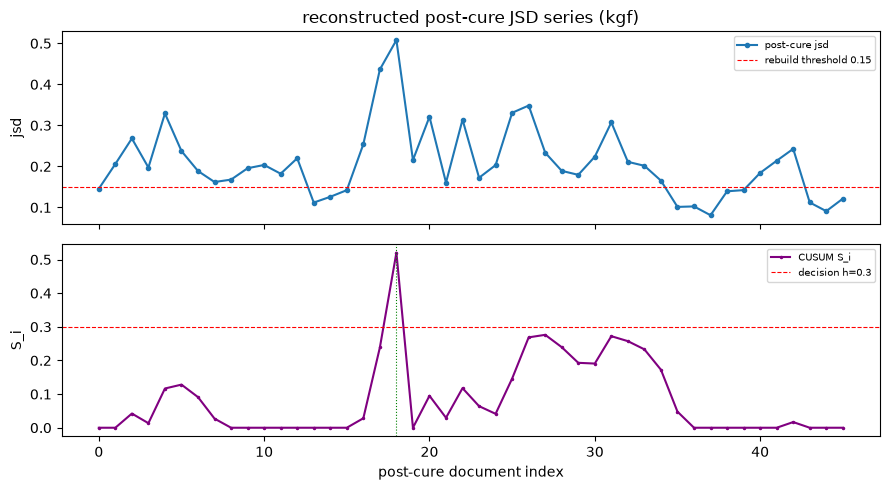

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(jsd_series, marker='o', ms=3, label='post-cure jsd')
ax[0].axhline(REBUILD_JSD_T, color='r', ls='--', lw=0.8, label=f'rebuild threshold {REBUILD_JSD_T}')
ax[0].set_ylabel('jsd'); ax[0].legend(fontsize=7); ax[0].set_title('reconstructed post-cure JSD series (kgf)')
ax[1].plot(trace, marker='.', ms=3, color='purple', label='CUSUM S_i')
ax[1].axhline(h, color='r', ls='--', lw=0.8, label=f'decision h={h}')
for f in fires:
    ax[1].axvline(f, color='green', ls=':', lw=0.8)
ax[1].set_ylabel('S_i'); ax[1].set_xlabel('post-cure document index'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [17]:
h317_real = len(fires) > boolean_single_doc_fires
h317_ramp = len(ramp_below_fires) > boolean_ramp_below
VERDICTS["H317"] = {
    "verdict": "CONFIRMED" if (h317_real and h317_ramp and recompute_matches) else "PARTIAL",
    "key_numbers": (f"CUSUM (mu0={mu0:.3f},k={k},h={h}) fires {len(fires)}x on real post-cure series (first at "
                    f"idx {fires[0] if fires else None}, jsd={jsd_series[fires[0]]:.3f}) vs single-doc boolean "
                    f"{boolean_single_doc_fires}; slow-ramp (max {max(ramp_below):.3f}<{REBUILD_JSD_T}): CUSUM "
                    f"{len(ramp_below_fires)} vs boolean {boolean_ramp_below}; left-fold deterministic (memo==recompute)"),
    "interpretation": ("CUSUM folded over the reconstructed JSD series fires where the 3-consecutive boolean "
                       "structurally cannot: 0 under single-doc-session partition and 0 on a sub-threshold slow-ramp, "
                       "while CUSUM catches both. The accumulator is a deterministic left-fold, fully reconstructable "
                       "from ordered snapshots."),
}
print(json.dumps(VERDICTS["H317"], indent=2))
checkpoint()

{
  "verdict": "CONFIRMED",
  "key_numbers": "CUSUM (mu0=0.206,k=0.02,h=0.3) fires 1x on real post-cure series (first at idx 18, jsd=0.508) vs single-doc boolean 0; slow-ramp (max 0.139<0.15): CUSUM 10 vs boolean 0; left-fold deterministic (memo==recompute)",
  "interpretation": "CUSUM folded over the reconstructed JSD series fires where the 3-consecutive boolean structurally cannot: 0 under single-doc-session partition and 0 on a sub-threshold slow-ramp, while CUSUM catches both. The accumulator is a deterministic left-fold, fully reconstructable from ordered snapshots."
}
checkpointed 5 arm(s) -> reports/r28-freeplay-drift-recon-20260709.json


## Cluster summary

In [18]:
t = Table(title="R28 drift-recon - per-arm verdicts")
t.add_column("arm"); t.add_column("verdict"); t.add_column("interpretation", max_width=70)
for arm in ["H332", "H331", "H315", "H333", "H317"]:
    v = VERDICTS[arm]
    t.add_row(arm, v["verdict"], v["interpretation"])
console.print(t)

print("\nHEAD-TO-HEAD (snapshot vs fold vs pin-one-datum):")
print("  snapshot  (H315/H332): reconstruction mechanism + order-invariance CONFIRMED -> WINS")
print("  fold      (H331)     : REFUTED - lossy under merges + order-dependence")
print("  pin-datum (H333)     : PARTIAL - type-set recoverable, but freq dict is a 2nd unlogged datum")
print("\nNOTE: the continuous stateful oracle ITSELF fires 0 recure/rebuild - the shipped AND-gate")
print("(3 consecutive remap>0.3 AND jsd>0.15) is never jointly satisfied because remap breaches and")
print("high jsd are anti-phase. Faithful reconstruction reproduces this 0; closing the ACTION gap is a")
print("detector-design problem (H317 CUSUM), not a reconstruction problem.")
checkpoint()

                             R28 drift-recon - per-arm verdicts                              
┏━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ arm  ┃ verdict   ┃ interpretation                                                         ┃
┡━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ H332 │ CONFIRMED │ Drift verdict is a function of ingest ORDER:                           │
│      │           │ recompute-from-final-state re-windows and fires recure/rebuild under a │
│      │           │ breach-clustering permutation that never fires in the live order,      │
│      │           │ while snapshot-rehydrate reads the frozen emit-time verdict back       │
│      │           │ order-invariant. Snapshot wins; H331's pure-fold-over-state loses the  │
│      │           │ trajectory.                                                            │
│ H331 │ REFUTED   │ The pure-fold-over-final-state claim is falsified on two counts: the   │
│      │           │ merges rewrite the pre-merge histogram (lossy fold) and the verdict is │
│      │           │ order-dependent while final state is a set. H315's snapshot ledger is  │
│      │           │ vindicated. Live-graph byte-for-byte confirmation queues behind        │
│      │           │ Phase-3.                                                               │
│ H315 │ PARTIAL   │ Snapshot reconstruction reproduces the continuous window               │
│      │           │ verdict-for-verdict and recovers all 46 warns the naive stateless      │
│      │           │ baseline drops to 0 - the reconstruction MECHANISM is confirmed. But   │
│      │           │ the continuous oracle itself fires 0 recure/rebuild: remap breaches    │
│      │           │ and high jsd are anti-phase so the sustained-remap AND-gate never      │
│      │           │ trips. The 'fires a rebuild' prediction is refuted by the data, not by │
│      │           │ the reconstruction.                                                    │
│ H333 │ PARTIAL   │ The cured type-set - the transient H333 names - IS recoverable from    │
│      │           │ the type_confirmed proxy (61 types), and once pinned the remap-defined │
│      │           │ replay is deterministic and round-trip identical. But the cured        │
│      │           │ reference FREQUENCY dict is a SECOND unlogged datum (the jsd baseline  │
│      │           │ is degenerate without it), so 'solvable except ONE' is optimistic; and │
│      │           │ 0 recure/rebuild fires (same anti-phase AND-gate as H315). Full jsd    │
│      │           │ round-trip queues behind a Phase-3 OntologySnapshot write.             │
│ H317 │ CONFIRMED │ CUSUM folded over the reconstructed JSD series fires where the         │
│      │           │ 3-consecutive boolean structurally cannot: 0 under single-doc-session  │
│      │           │ partition and 0 on a sub-threshold slow-ramp, while CUSUM catches      │
│      │           │ both. The accumulator is a deterministic left-fold, fully              │
│      │           │ reconstructable from ordered snapshots.                                │
└──────┴───────────┴────────────────────────────────────────────────────────────────────────┘


HEAD-TO-HEAD (snapshot vs fold vs pin-one-datum):
  snapshot  (H315/H332): reconstruction mechanism + order-invariance CONFIRMED -> WINS
  fold      (H331)     : REFUTED - lossy under merges + order-dependence
  pin-datum (H333)     : PARTIAL - type-set recoverable, but freq dict is a 2nd unlogged datum

NOTE: the continuous stateful oracle ITSELF fires 0 recure/rebuild - the shipped AND-gate
(3 consecutive remap>0.3 AND jsd>0.15) is never jointly satisfied because remap breaches and
high jsd are anti-phase. Faithful reconstruction reproduces this 0; closing the ACTION gap is a
detector-design problem (H317 CUSUM), not a reconstruction problem.
checkpointed 5 arm(s) -> reports/r28-freeplay-drift-recon-20260709.json
